#downloading dataset

In [2]:
medical_charges_url='https://github.com/stedy/Machine-Learning-with-R-datasets/blob/master/insurance.csv'

In [3]:
from urllib.request import urlretrieve

In [4]:
urlretrieve('https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv','medical.csv')

('medical.csv', <http.client.HTTPMessage at 0x7dcd1055ccd0>)

In [5]:
!pip install pandas --quiet
import pandas as pd

In [6]:
medical_df=pd.read_csv('medical.csv')

In [7]:
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [8]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


#exploratory analysis and visualization

In [10]:
!pip install plotly matplotlib seaborn --quiet
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [11]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size']=14
matplotlib.rcParams['figure.figsize']=(10,6)
matplotlib.rcParams['figure.facecolor']='#00000000'

##Age

In [12]:
medical_df.age.describe()

,age
count,1338.000000
mean,39.207025
std,14.049960
min,18.000000
25%,27.000000
50%,39.000000
75%,51.000000
max,64.000000


In [13]:
fig=px.histogram(medical_df,
                 x='age',
                 marginal='box',
                 nbins=47,
                 title='Distribution of Age')

fig.update_layout(bargap=0.1)
fig.show()


##BMI

In [14]:
medical_df.bmi.describe()

,bmi
count,1338.000000
mean,30.663397
std,6.098187
min,15.960000
25%,26.296250
50%,30.400000
75%,34.693750
max,53.130000


In [15]:
fig=px.histogram(medical_df,
                 x='bmi',
                 marginal='box',
                 color_discrete_sequence=['red'],
                 title='Distribution of BMI(Body Mass Index)')

fig.update_layout(bargap=0.1)
fig.show()

##Charges

In [16]:
medical_df.charges.describe()

,charges
count,1338.000000
mean,13270.422265
std,12110.011237
min,1121.873900
25%,4740.287150
50%,9382.033000
75%,16639.912515
max,63770.428010


In [17]:
fig=px.histogram(medical_df,
                 x='charges',
                 marginal='box',
                 color='smoker',
                 color_discrete_sequence=['green','grey'],
                 title='Annual Medical Charges')

fig.update_layout(bargap=0.1)
fig.show()

Ex:other factors like sex and region

In [18]:
fig=px.histogram(medical_df,
                 x='charges',
                 color='region',
                 color_discrete_sequence=['green','grey'],
                 title='Annual Medical Charges by Region')

fig.update_layout(bargap=0.1)
fig.show()

In [19]:
fig = px.box(medical_df,
             x='region',
             y='charges',
             color='sex',
             title='Medical Charges by Region and Gender')

fig.update_layout(bargap=0.1)
fig.show()

In [20]:
fig=px.histogram(medical_df,
                 x='sex',
                 color='region',
                 color_discrete_sequence=['green','grey'],
                 title='region and sex')

fig.update_layout(bargap=0.1)
fig.show()

##Smoker

In [21]:
medical_df.smoker.value_counts()

,count
smoker,
no,1064
yes,274


In [22]:
fig=px.histogram(medical_df,
                 x='smoker',
                 color='sex',
                 title='Smoker'
                 )
fig.update_layout(bargap=0.1)
fig.show()

Ex:distributions based on sex region and children

In [23]:
fig = px.histogram(medical_df, x='sex', title='Distribution of Sex')
fig.show()

fig = px.histogram(medical_df, x='region', title='Distribution of Region')
fig.show()

fig = px.histogram(medical_df, x='children', title='Distribution of Children')
fig.show()

##Age and Charges

Relationship b/w age and charges using scatter plot.Each point in the scatter represents one customer

In [24]:
fig=px.scatter(medical_df,
                x='age',
                y='charges',
                color='smoker',
                opacity=0.8,
                hover_data=['sex'],
                title='Age Vs Charges')

fig.update_traces(marker_size=5)
fig.show()

##BMI and Charges

In [25]:
fig=px.scatter(medical_df,
               x='bmi',
               y='charges',
               color='smoker',
               opacity=0.8,
               hover_data=['sex'],
               title='BMI Vs Charges')

fig.update_traces(marker_size=5)
fig.show()

Create some graphs to visualize how the charges column is related to other columns(children sex region and smoker).Summarize the insights gathered from the graphs.

Hint:use px.violin and sns.barplot

In [26]:
fig = px.violin(medical_df, x='children', y='charges', title='Charges vs. Children')
fig.show()

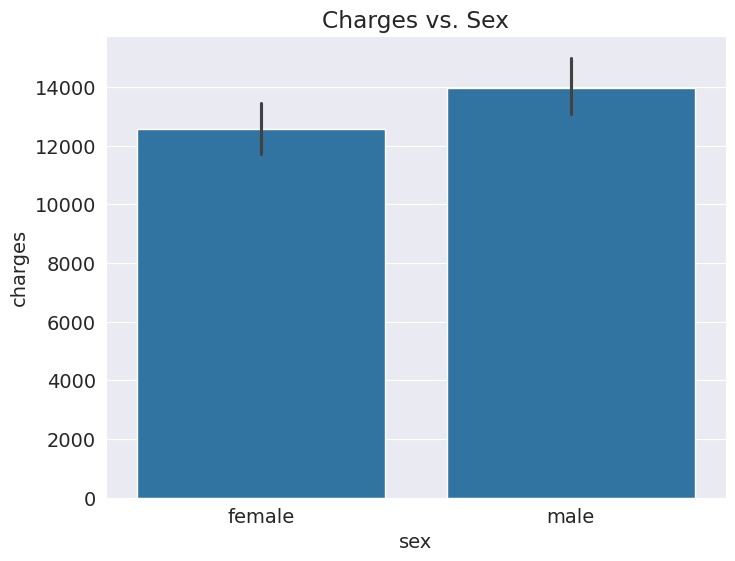

In [27]:
plt.figure(figsize=(8, 6))
sns.barplot(x='sex', y='charges', data=medical_df)
plt.title('Charges vs. Sex')
plt.show()

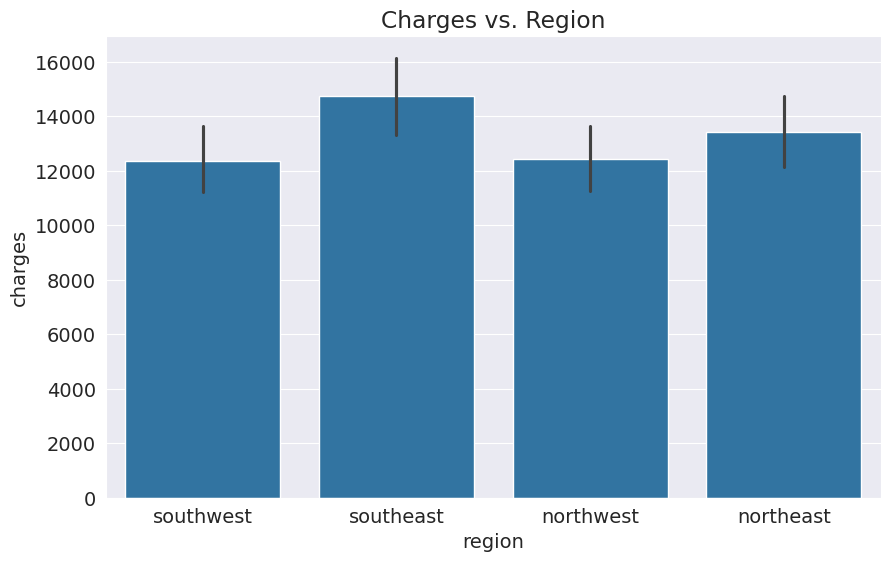

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(x='region', y='charges', data=medical_df)
plt.title('Charges vs. Region')
plt.show()

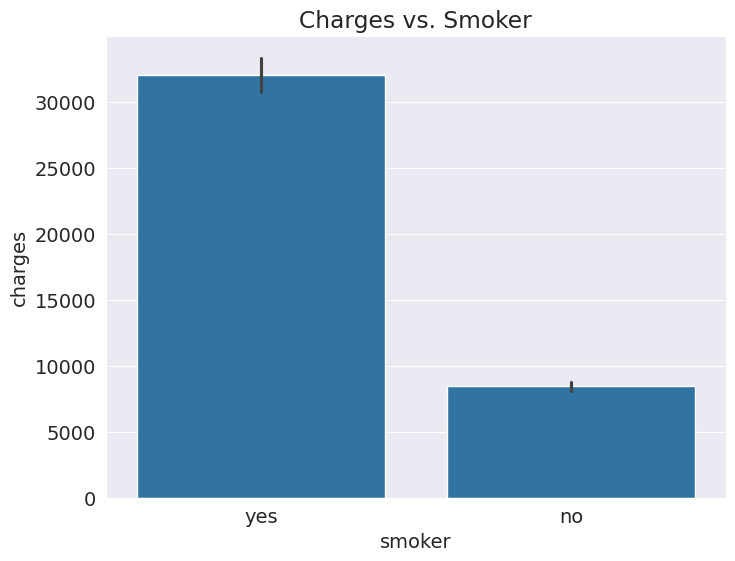

In [29]:
plt.figure(figsize=(8, 6))
sns.barplot(x='smoker', y='charges', data=medical_df)
plt.title('Charges vs. Smoker')
plt.show()

##Correlation

In [30]:
medical_df.charges.corr(medical_df.age)

np.float64(0.2990081933306476)

In [31]:
medical_df.charges.corr(medical_df.bmi)

np.float64(0.19834096883362895)

In [32]:
medical_df.charges.corr(medical_df.children)

np.float64(0.06799822684790478)

To compute the correlation to categorical columns, they must first be converted into numeric columns

In [33]:
medical_df.smoker

,smoker
0,yes
1,no
2,no
3,no
4,no
...,...
1333,no
1334,no
1335,no
1336,no


In [34]:
smoker_values={'no':0,'yes':1}
smoker_numeric=medical_df.smoker.map(smoker_values)
smoker_numeric

,smoker
0,1
1,0
2,0
3,0
4,0
...,...
1333,0
1334,0
1335,0
1336,0


In [35]:
medical_df.charges.corr(smoker_numeric)

np.float64(0.787251430498478)

How correlation coeff can be interpreted:

Strength:The greater the absolute value of the correlation coeff, the stronger the rel

Direction:The sign of the correaltion coeff rep the direction of the rel


In [36]:
px.scatter(medical_df,x='age',y='age')

In [37]:
medical_df.select_dtypes(include='number').corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


Text(0.5, 1.0, 'Correlation Matrix')

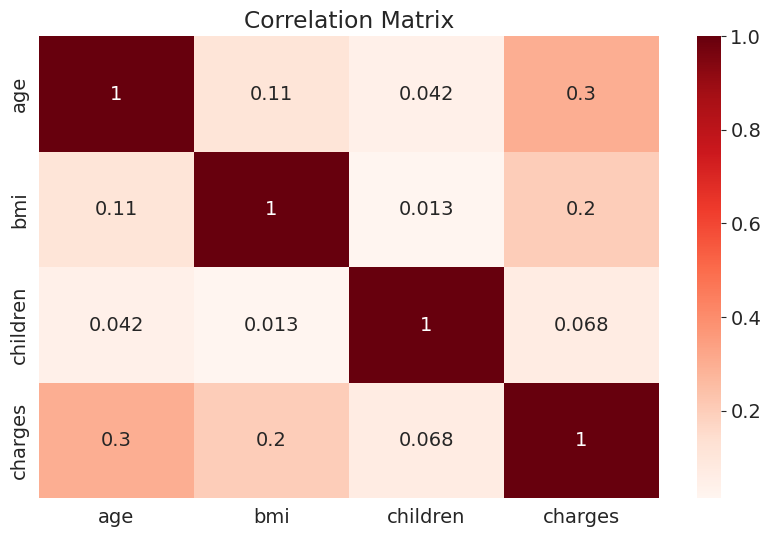

In [38]:
sns.heatmap(medical_df.select_dtypes(include='number').corr(),cmap='Reds',annot=True)
plt.title('Correlation Matrix')

#Linear Regression using a single feature

In [39]:
non_smoker_df=medical_df[medical_df.smoker=='no']

Relationship b/w age and charges

<Axes: title={'center': 'Age Vs Charges'}, xlabel='age', ylabel='charges'>

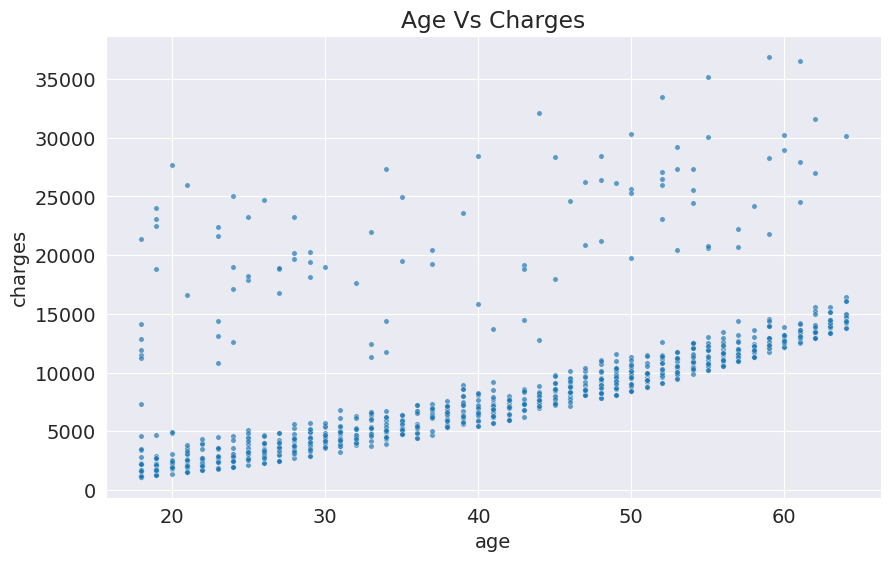

In [40]:
plt.title('Age Vs Charges')
sns.scatterplot(data=non_smoker_df,x='age',y='charges',alpha=0.7,s=15)

charges=w x age + b

In [41]:
def estimate_charges(age,w,b):
  return w*age+b

In [42]:
w=50
b=100

In [43]:
estimate_charges(40,w,b)

2100

In [44]:
ages=non_smoker_df.age
ages

,age
1,18
2,28
3,33
4,32
5,31
...,...
1332,52
1333,50
1334,18
1335,18


In [45]:
estimated_charges=estimate_charges(ages,w,b)
estimated_charges

,age
1,1000
2,1500
3,1750
4,1700
5,1650
...,...
1332,2700
1333,2600
1334,1000
1335,1000


In [46]:
non_smoker_df.charges

,charges
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
5,3756.62160
...,...
1332,11411.68500
1333,10600.54830
1334,2205.98080
1335,1629.83350


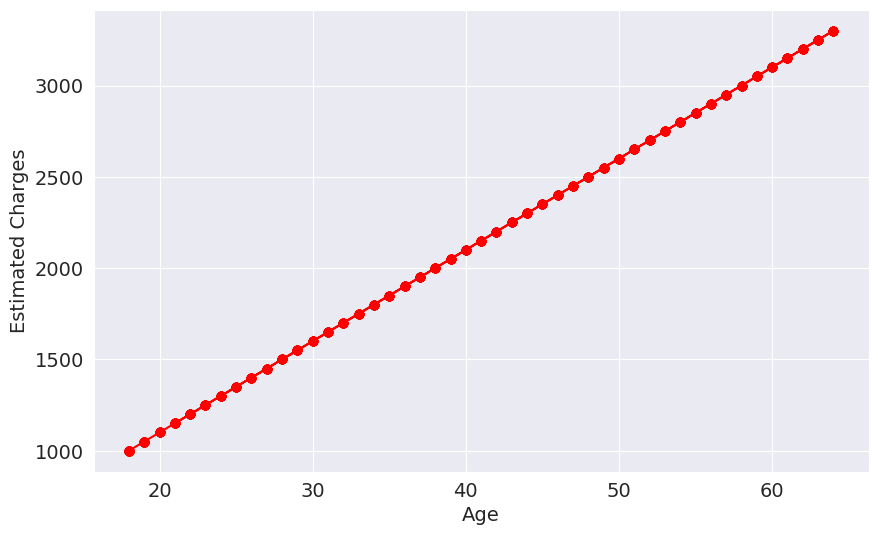

In [47]:
plt.plot(ages,estimated_charges,'r-o');
plt.xlabel('Age');
plt.ylabel('Estimated Charges');

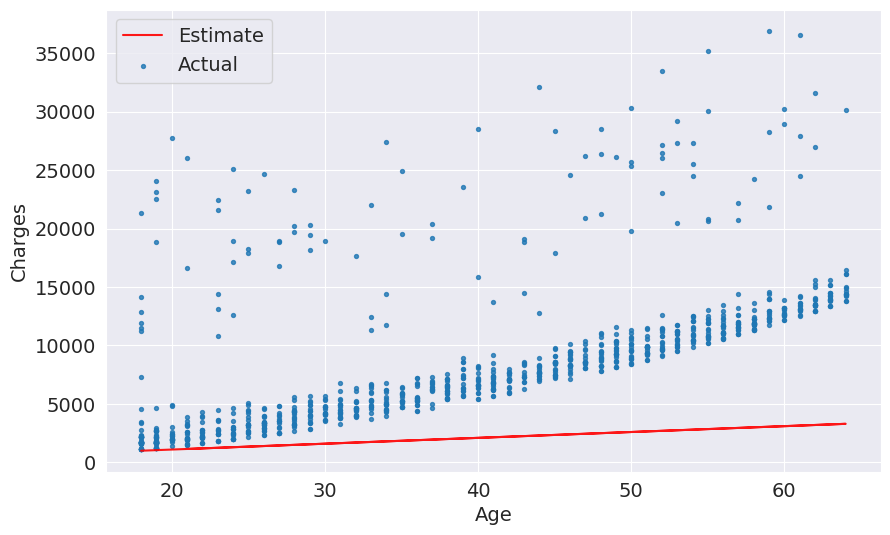

In [48]:
target=non_smoker_df.charges

plt.plot(ages,estimated_charges,'r',alpha=.9)
plt.scatter(ages,target,s=8,alpha=.8)
plt.xlabel('Age');
plt.ylabel('Charges')
plt.legend(['Estimate','Actual'])


In [49]:
def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, 'r', alpha=.9)
    plt.scatter(ages, target, s=8, alpha=.8)
    plt.xlabel('Age')
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual'])

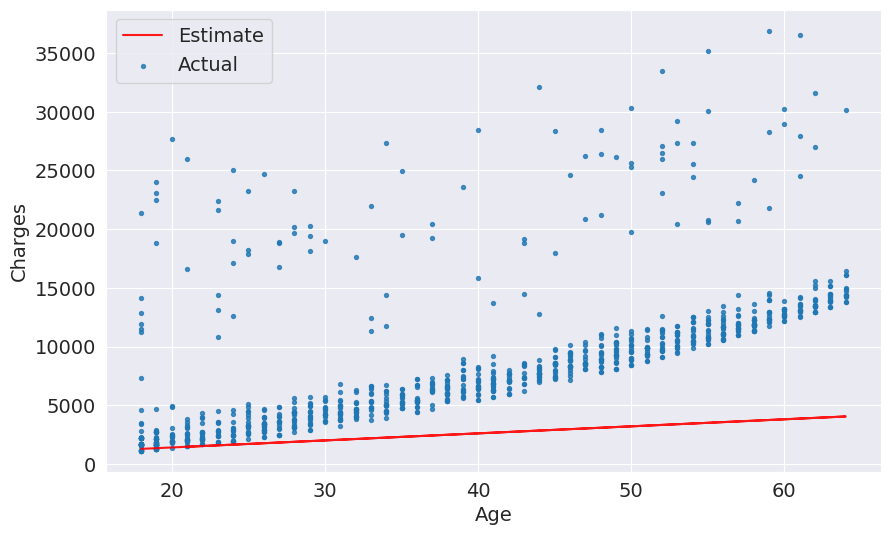

In [50]:
try_parameters(60,200)

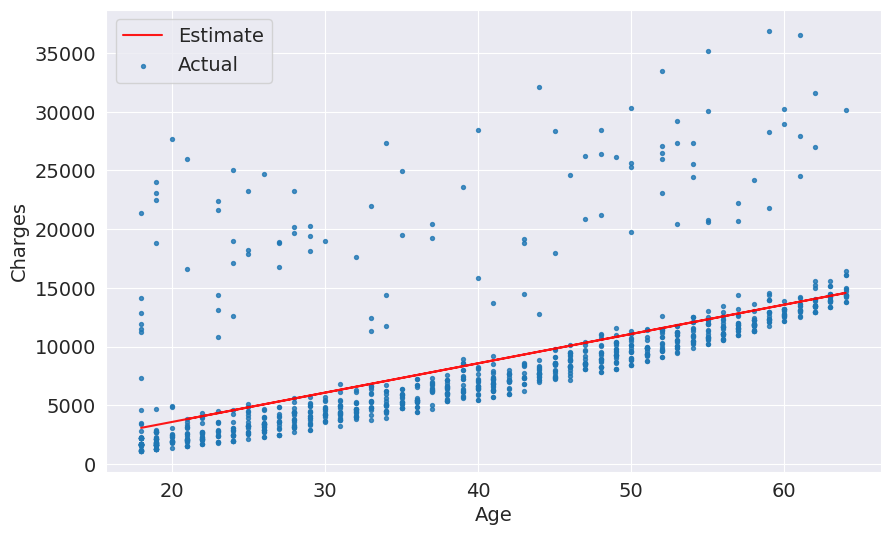

In [51]:
try_parameters(250,-1430)

In [52]:
targets=non_smoker_df.charges
targets

,charges
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
5,3756.62160
...,...
1332,11411.68500
1333,10600.54830
1334,2205.98080
1335,1629.83350


In [53]:
predictions=estimate_charges(ages,w,b)
predictions

,age
1,1000
2,1500
3,1750
4,1700
5,1650
...,...
1332,2700
1333,2600
1334,1000
1335,1000


##loss/cost function

In [54]:
!pip install numpy --quiet
import numpy as np

In [55]:
def rmse(targets,predictions):
  return np.sqrt(np.mean((targets-predictions)**2))

In [56]:
w=250
b=-1400

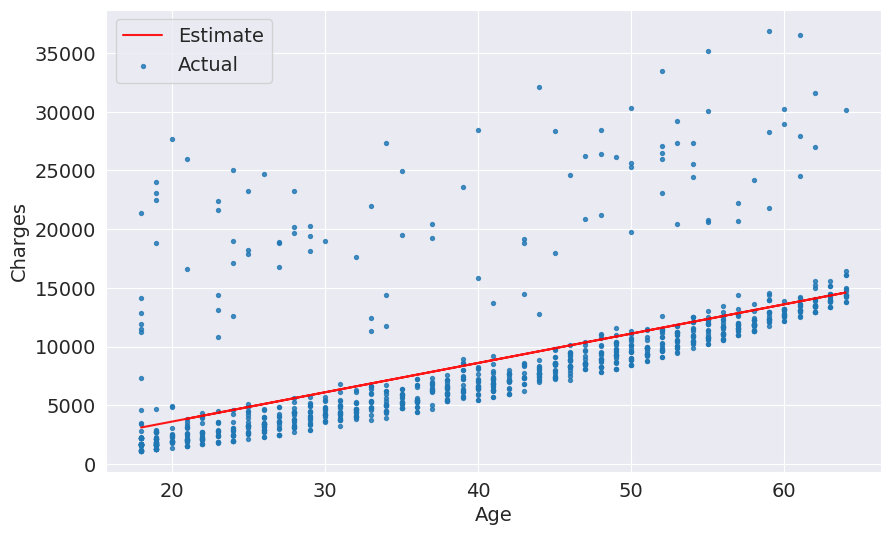

In [57]:
try_parameters(w,b)

In [58]:
targets=non_smoker_df.charges
predicted=estimate_charges(non_smoker_df.age,w,b)

In [59]:
rmse(targets,predicted)

np.float64(4668.83946924171)

In [60]:
def try_parameters(w,b):
  ages=non_smoker_df.age
  target=non_smoker_df.charges
  predictions=estimate_charges(ages,w,b)

  plt.plot(ages,predictions,'r',alpha=.9)
  plt.scatter(ages,target,s=8,alpha=.8)
  plt.xlabel('Age')
  plt.ylabel('Charges')
  plt.legend(['Prediction','Actual'])

  loss=rmse(target,predictions)
  print(f'RMSE={loss}')

RMSE=4670.168652979376


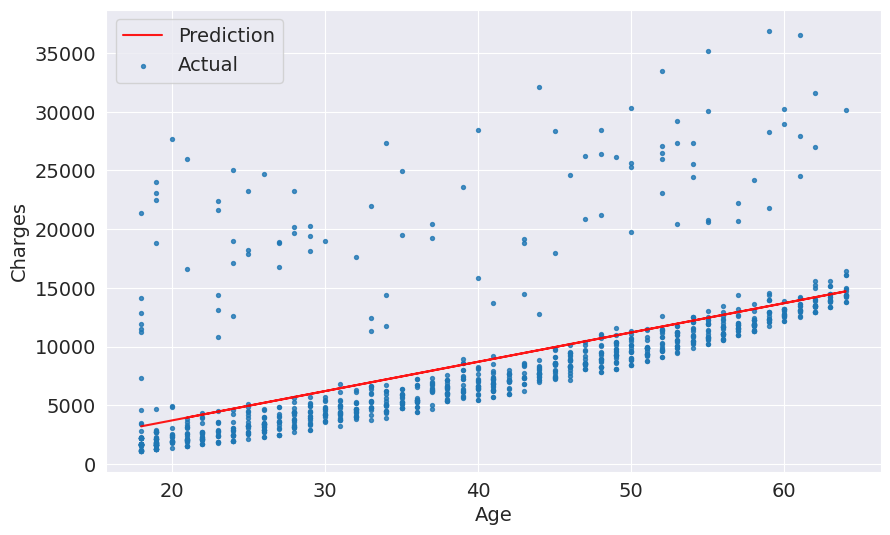

In [61]:
try_parameters(250,-1300)

####Optimizer

ordinary least square(smaller datasets)

stochastic gradient descent(larger datasets)

####linear regsression using scikit-learn

In [62]:
!pip install scikit-learn --quiet
from sklearn.linear_model import LinearRegression

In [63]:
model=LinearRegression()

In [64]:
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.
    
    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.
    
    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.
    
    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.
    
        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.
    
    Returns
    -------
    self : object
        Fitted Estimator.



In [65]:
inputs=non_smoker_df[['age']]
targets=non_smoker_df.charges
print(f'input.shape: {inputs.shape}')
print(f'targets.shape: {targets.shape}')

input.shape: (1064, 1)
targets.shape: (1064,)


In [66]:
model.fit(inputs,targets)

LinearRegression()

In [67]:
model.predict(np.array([[23],
                       [37],
                       [61]]
                       ))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [68]:
predictions=model.predict(inputs)
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

In [69]:
targets

,charges
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
5,3756.62160
...,...
1332,11411.68500
1333,10600.54830
1334,2205.98080
1335,1629.83350


In [70]:
rmse(targets,predictions)

np.float64(4662.505766636395)

In [71]:
#w
model.coef_

array([267.24891283])

In [72]:
#b
model.intercept_

np.float64(-2091.4205565650864)

RMSE=4662.505766636395


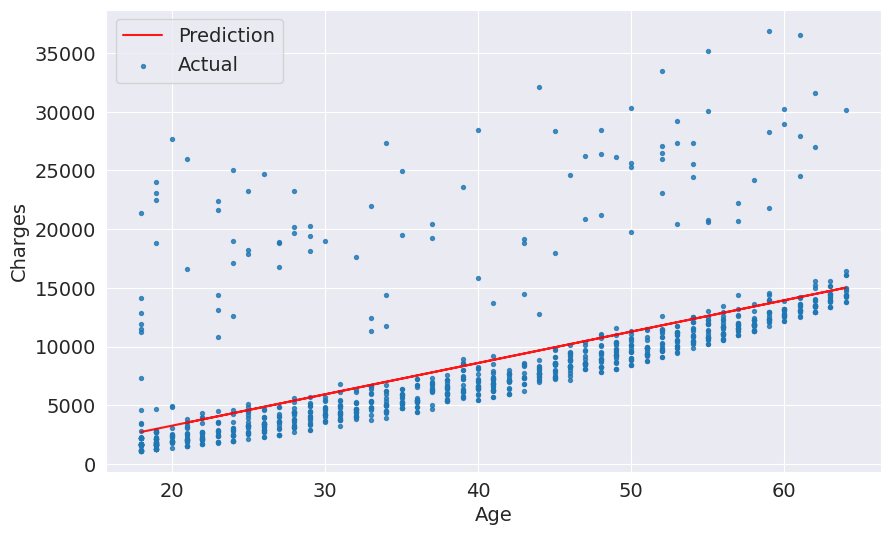

In [73]:
try_parameters(model.coef_,model.intercept_)

#Ml

In [74]:
from logging import logProcesses
#create inputs and targets
inputs, targets=non_smoker_df[['age']],non_smoker_df['charges']

#create and train the model
model=LinearRegression().fit(inputs,targets)

#generate predictions
predictions=model.predict(inputs)

#compute loss ti evaluate the model
loss=rmse(targets,predictions)
print(f'Loss: {loss}')

Loss: 4662.505766636395


##linear regression using multiple features

* charges=w1*age+w2*bmi+b

In [75]:
from logging import logProcesses
#create inputs and targets
inputs, targets=non_smoker_df[['age','bmi']],non_smoker_df['charges']

#create and train the model
model=LinearRegression().fit(inputs,targets)

#generate predictions
predictions=model.predict(inputs)

#compute loss ti evaluate the model
loss=rmse(targets,predictions)
print(f'Loss: {loss}')

Loss: 4662.3128354612945


In [76]:
non_smoker_df.charges.corr(non_smoker_df.bmi)

np.float64(0.0840365431283327)

In [77]:
fig=px.scatter(non_smoker_df,
               x='bmi',
               y='charges',
               title='BMI Vs Charges')

fig.update_traces(marker_size=5)
fig.show()

In [78]:
import plotly.express as px

fig = px.scatter_3d(non_smoker_df,
                    x='age',
                    y='bmi',
                    z='charges',
                    title='BMI vs Charges vs Age',
                    color='charges')

fig.update_traces(marker=dict(size=3))
fig.show()


In [79]:
model.coef_,model.intercept_

(array([266.87657817,   7.07547666]), np.float64(-2293.6320906488727))

* charges=w1*age+w2*bmi+w3*charges+b

In [80]:
fig=px.strip(non_smoker_df,
             x='children',
             y='charges',
             title='children vs charges',
             )

fig.update_traces(marker_size=4,marker_opacity=.7)
fig.show()

In [81]:
from logging import logProcesses
#create inputs and targets
inputs, targets=non_smoker_df[['age','bmi','children']],non_smoker_df['charges']

#create and train the model
model=LinearRegression().fit(inputs,targets)

#generate predictions
predictions=model.predict(inputs)

#compute loss ti evaluate the model
loss=rmse(targets,predictions)
print(f'Loss: {loss}')

Loss: 4608.470405038247


In [82]:
#create inputs &  targets
inputs, targets=medical_df[['age','bmi','children']],medical_df['charges']

#create and train the model
model=LinearRegression().fit(inputs,targets)

#generate predictions
predictions=model.predict(inputs)

#compute loss ti evaluate the model
loss=rmse(targets,predictions)
print(f'Loss: {loss}')

Loss: 11355.317901125973


In [83]:
fig = px.scatter_3d(medical_df,
                   x='age',
                   y='charges',
                   color='smoker'
                   )

fig.show()

#Using categorical features fo ML


1. If a categorical column has just two categories , then we can replace their values with 0 and 1.
2. If a categorical col has more than 2 categories, we can perform one-hot encoding i.e create a new column for each category with 1s and 0s.
3. If the categories have a natural order(cold,neutral,warm,hot), they can be converted to numbers(1,2,3,4)preserving the order.These are called ordinals.

##binary categories


smoker cat just has yes nad no
smoker_code 0 for no 1 for yes

<Axes: xlabel='smoker', ylabel='charges'>

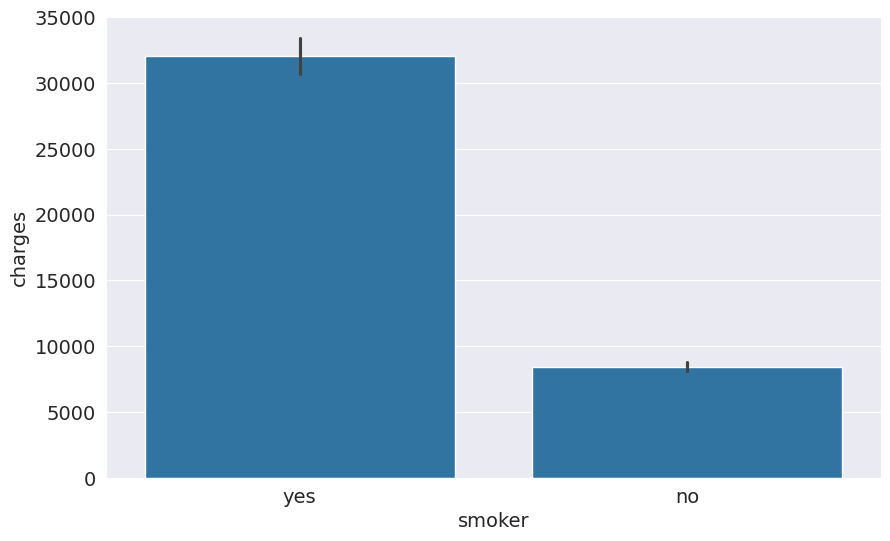

In [84]:
sns.barplot(data=medical_df,x='smoker',y='charges')

In [85]:
smoker_codes={'no':0,'yes':1}
medical_df['smoker_code']=medical_df.smoker.map(smoker_codes)

In [86]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


In [87]:
medical_df.charges.corr(medical_df.smoker_code)

np.float64(0.787251430498478)

We can now use the `smoker_code` column for linear regression.

$charges=w_l × ages + w_2 × bmi + w_3 × charges + w_4 × smoker +b$

In [88]:
#create inputs and targets
inputs, targets=medical_df[['age','bmi','children','smoker_code']],medical_df['charges']

#create and train the model
model=LinearRegression().fit(inputs,targets)

#gen predicitions
predictions=model.predict(inputs)

#compute loss to evaluate the model
loss=rmse(targets,predictions)
print(f'Loss: {loss}')

Loss: 6056.439217188081


the loss reduces from `11355` to `6056` almost 50% .
- Never ignore categorical data

* try adding sex
$charges=w_1 × age + w_2 × bmi+ w_3 × charges + w_4 × smoker + w_5 × sex + b$

<Axes: xlabel='sex', ylabel='charges'>

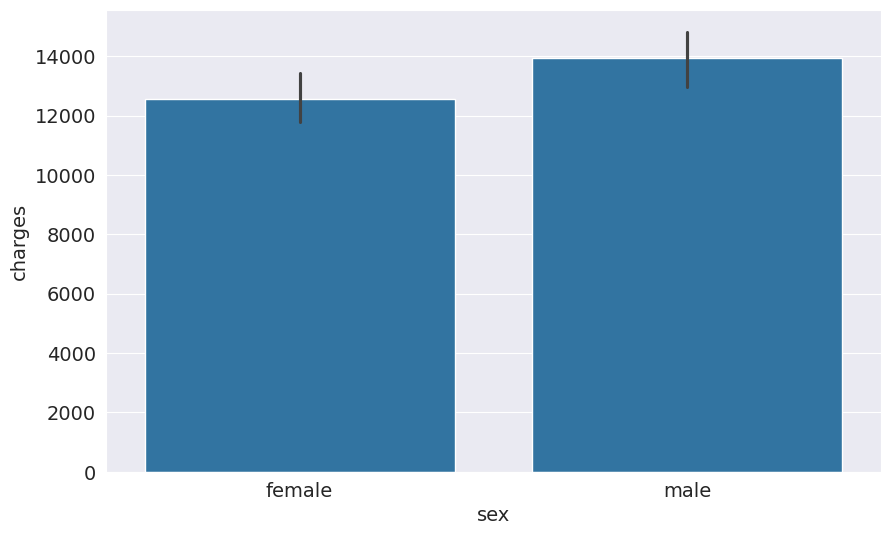

In [89]:
sns.barplot(data=medical_df,x='sex',y='charges')

In [90]:
sex_codes={'female':0,'male':1}

In [91]:
medical_df['sex_code']=medical_df.sex.map(sex_codes)

In [92]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code
0,19,female,27.900,0,yes,southwest,16884.92400,1,0
1,18,male,33.770,1,no,southeast,1725.55230,0,1
2,28,male,33.000,3,no,southeast,4449.46200,0,1
3,33,male,22.705,0,no,northwest,21984.47061,0,1
4,32,male,28.880,0,no,northwest,3866.85520,0,1
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1
1334,18,female,31.920,0,no,northeast,2205.98080,0,0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0


In [93]:
medical_df.charges.corr(medical_df.sex_code)

np.float64(0.057292062202025484)

In [94]:
#create inputs and targets
inputs, targets=medical_df[['age','bmi','children','smoker_code','sex_code']],medical_df['charges']

#create and train the model
model=LinearRegression().fit(inputs,targets)

#gen predicitions
predictions=model.predict(inputs)

#compute loss to evaluate the model
loss=rmse(targets,predictions)
print(f'Loss: {loss}')

Loss: 6056.100708754546


#one-hot encoding

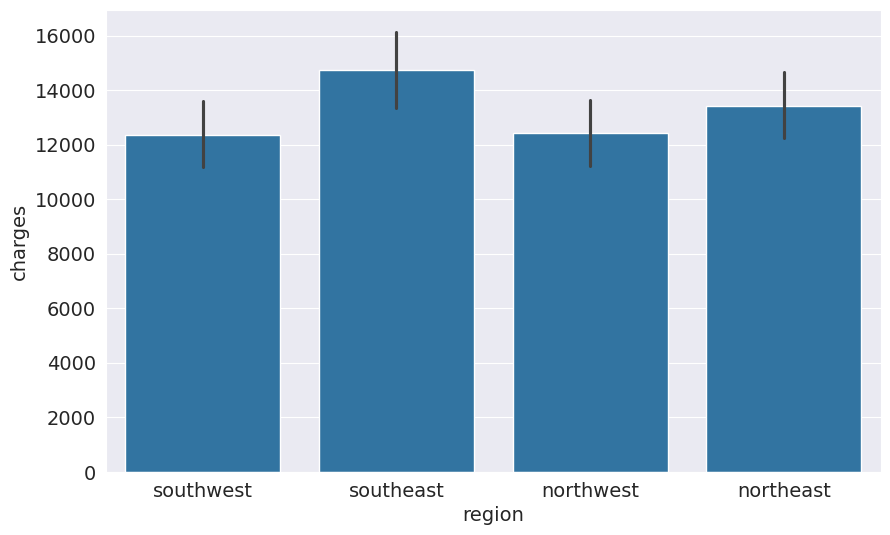

In [95]:
sns.barplot(data=medical_df,x='region',y='charges');

In [96]:
from sklearn import  preprocessing
enc=preprocessing.OneHotEncoder()
enc.fit(medical_df[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [97]:
enc.transform([['northwest'],['northeast']]).toarray()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but OneHotEncoder was fitted with feature names



array([[0., 1., 0., 0.],
       [1., 0., 0., 0.]])

In [98]:
medical_df[['region']]

,region
0,southwest
1,southeast
2,southeast
3,northwest
4,northwest
...,...
1333,northwest
1334,northeast
1335,southeast
1336,southwest


In [99]:
one_hot=enc.transform(medical_df[['region']]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]])

In [100]:
medical_df[['northeast','northwest','southeast','southwest']]=one_hot

In [101]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


$charges=w_1 × age+ w_2 × bmi+ w_3 × charges+ w_4 × smoker + w_5 × sex + w_6 × northeast + w_7 × northwest + w_8 × southeast + w_9 × southwest + b$





In [102]:
#create inputs and targets
inputs, targets=medical_df[['age','bmi','children','smoker_code','sex_code','northeast','northwest','southeast','southwest']],medical_df['charges']

#create and train the model
model=LinearRegression().fit(inputs,targets)

#gen predicitions
predictions=model.predict(inputs)

#compute loss to evaluate the model
loss=rmse(targets,predictions)
print(f'Loss: {loss}')

Loss: 6041.6796511744515


#model improvment

In [103]:
medical_df[inputs.columns].loc[10]

,10
age,25.00
bmi,26.22
children,0.00
smoker_code,0.00
sex_code,1.00
northeast,1.00
northwest,0.00
southeast,0.00
southwest,0.00


In [104]:
model.predict([[28,25,2,1,1,0,0,0,0]])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([27814.48767294])

featuring scale

$charges=w_1 × age+ w_2 × bmi+ w_3 × charges+ w_4 × smoker + w_5 × sex + w_6 × region + b$





In [105]:
model.coef_

array([  256.85635254,   339.19345361,   475.50054515, 23848.53454191,
        -131.3143594 ,   587.00923503,   234.0453356 ,  -448.01281436,
        -373.04175627])

In [106]:
model.intercept_

np.float64(-12525.547811195444)

In [107]:
weights_df=pd.DataFrame({'feature':np.append(inputs.columns,1),'weight':np.append(model.coef_,model.intercept_)})
weights_df

,feature,weight
0,age,256.856353
1,bmi,339.193454
2,children,475.500545
3,smoker_code,23848.534542
4,sex_code,-131.314359
5,northeast,587.009235
6,northwest,234.045336
7,southeast,-448.012814
8,southwest,-373.041756
9,1,-12525.547811


standardization

In [108]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [109]:
from sklearn.preprocessing import StandardScaler

In [111]:
numeric_cols=['age','bmi','children']
scaler=StandardScaler()
scaler.fit(medical_df[numeric_cols])

StandardScaler()

In [112]:
scaler.mean_

array([39.20702541, 30.66339686,  1.09491779])

In [113]:
scaler.var_

array([197.25385199,  37.16008997,   1.45212664])

In [114]:
medical_df[numeric_cols]

,age,bmi,children
0,19,27.900,0
1,18,33.770,1
2,28,33.000,3
3,33,22.705,0
4,32,28.880,0
...,...,...,...
1333,50,30.970,3
1334,18,31.920,0
1335,18,36.850,0
1336,21,25.800,0


In [115]:
scaler_inputs=scaler.transform(medical_df[numeric_cols])
scaler_inputs

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]])

In [116]:
cat_cols=['smoker_code','sex_code','northeast','northwest','southeast','southwest']
categorical_data=medical_df[cat_cols].values

In [119]:
inputs[0]

array([-1.43876426, -0.45332   , -0.90861367,  1.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  1.        ])

In [120]:
inputs=np.concatenate([scaler_inputs,categorical_data],axis=1)
targets=medical_df.charges

# create and train the model
model = LinearRegression().fit(inputs, targets)

# generate predictions
predictions = model.predict(inputs)

# compute loss to evaluate the model
loss = rmse(targets, predictions)
print(f'Loss: {loss}')

Loss: 6041.6796511744515


$charges=w_1 × age+ w_2 × bmi+ w_3 × charges+ w_4 × smoker + w_5 × sex + w_6 × region + b$





In [128]:
model.coef_

array([ 3607.47273619,  2067.69196584,   572.99820995, 23848.53454191,
        -131.3143594 ,   587.00923503,   234.0453356 ,  -448.01281436,
        -373.04175627])

In [127]:
weights_df=pd.DataFrame({
    'feature':np.append(numeric_cols+cat_cols,1),
    'weight':np.append(model.coef_,model.intercept_)
})
weights_df.sort_values('weight',ascending=False)


,feature,weight
3,smoker_code,23848.534542
9,1,8466.483215
0,age,3607.472736
1,bmi,2067.691966
5,northeast,587.009235
2,children,572.998210
6,northwest,234.045336
4,sex_code,-131.314359
8,southwest,-373.041756
7,southeast,-448.012814


In [129]:
new_customers=[[24,28,2,1,0,0,1,0,0]]

In [131]:
scaler.transform([[24,28,2]])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



array([[-1.08275831, -0.43691555,  0.75107928]])

In [132]:
model.predict([[-1.08275831, -0.43691555,  0.75107928,1,0,0,1,0,0]])

array([28170.0023202])

### How to approach a ML problem
1. explore the data and find correlations b/w inputs and targets

2. pick the right model, loss functions and optimizer for the problem at hand

3. scale numeric variables and one-hot encode categorical data

4. Set aside a test set(using a fraction of the training set)
5. train the model
6. make predicitions on the test set and compute the loss
